# Estimate Motor Noise from Lateral Localization Error

**Approach:**
1. Compute sdL from real behavioral data
2. Run ITD+ILD-only model (fixed params, no spectral) to get internal estimates
3. Fit sigma_motor via ML using von Mises distribution on lateral angle

Exploratory development of stage 1 of the fitting procedure (Sec. 2.2.2), now implemented as
`bayesian_listener.fitting.estimate_motor_noise` and used by `07_fit_all_participants.ipynb`.
Needs the participant HRTFs (`data/hrtf/`) and the behavioural data (`data/behavioural/`).
Saved outputs are from a development version of `bayesian_listener` preceding 0.2.0.

In [25]:
import numpy as np
import pandas as pd
import pyfar as pf
from pathlib import Path
from scipy.special import i0, i1
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

from bayesian_listener import BayesianListener

import paths

def wrap_to_pi(rad):
    """Wrap angles to [-π, π)."""
    return (rad + np.pi) % (2 * np.pi) - np.pi

# Behavioural data (target directions and responses)
dirs = pd.read_csv(paths.DIRS_FILE)
_dirs_arr = np.column_stack([np.deg2rad(dirs['azi_target'].values), np.deg2rad(dirs['ele_target'].values), np.ones(len(dirs))])
targets_coords = pf.Coordinates.from_spherical_elevation(_dirs_arr[:, 0], _dirs_arr[:, 1], _dirs_arr[:, 2])

obs_tbl = pd.read_csv(paths.BEHAV_FILE)
obs_tbl = obs_tbl[(obs_tbl['condition'] == 'Measured')]
obs_tbl = obs_tbl[(obs_tbl['participant'] != 'P0247')]
trial_counts = obs_tbl.groupby('participant').size()
participants = obs_tbl['participant'].unique()
print(f"Participants: {len(participants)}")

Participants: 33


In [ ]:

def sdL(true, est):
    """Compute lateral SD error within ±80° lateral."""
    lat_true = wrap_to_pi(true[..., 0])
    lat_est = wrap_to_pi(est[..., 0])
    mask = np.abs(lat_true) <= np.deg2rad(30)
    if not np.any(mask):
        return np.nan
    diff = wrap_to_pi(lat_est - lat_true)[mask]
    return np.sqrt(np.var(diff))

def rmsL(true, est, cutoff=30):
    lat_true = wrap_to_pi(true[..., 0])
    lat_est = wrap_to_pi(est[..., 0])
    mask = np.abs(lat_true) <= np.deg2rad(cutoff)
    if not np.any(mask):
        return np.nan
    diff = wrap_to_pi(lat_est - lat_true)[mask]
    return np.sqrt(np.mean(diff**2))


## Helper functions

In [27]:
def von_mises_loglik_mc(kappa, resp_lat, est_lat_mc):
    """
    Negative log-likelihood for von Mises with MC estimates.

    resp_lat: (n_trials,) response lateral angles
    est_lat_mc: (n_trials, n_mc) MC estimates of lateral angles
    """
    # von Mises log normalization: log(1 / (2*pi*I0(kappa)))
    log_C = -np.log(2 * np.pi * i0(kappa))

    # Lateral error for each (trial, mc) pair
    # log p = log_C + kappa * cos(resp - est)
    lat_diff = resp_lat[:, None] - est_lat_mc  # (n_trials, n_mc)
    log_pdfs = log_C + kappa * np.cos(lat_diff)  # (n_trials, n_mc)

    # Average over MC samples using log-sum-exp
    max_log_pdfs = np.max(log_pdfs, axis=1, keepdims=True)  # (n_trials, 1)
    log_mean_probs = max_log_pdfs[:, 0] + np.log(np.mean(np.exp(log_pdfs - max_log_pdfs), axis=1))

    return -np.sum(log_mean_probs)

def fit_kappa_ml(resp_lat, est_lat_mc):
    """ML estimate of kappa given responses and MC estimates."""
    result = minimize_scalar(von_mises_loglik_mc, bounds=(0.1, 1000),
                            args=(resp_lat, est_lat_mc), method='bounded')
    return result.x

def kappa_to_sigma(kappa):
    """Convert von Mises kappa to circular std dev (degrees)."""
    if kappa < 1e-6:
        return 180.0
    R = i1(kappa) / i0(kappa)
    return np.rad2deg(np.sqrt(-2 * np.log(R)))

## Fit motor noise for all participants

In [28]:
results = []
targets_hp = targets_coords.spherical_side

# Fixed ITD+ILD noise parameters
sigma_itd = 0.569
sigma_ild = 1.0
n_mc = 100  # MC repetitions per trial

np.random.seed(42)

for pid in participants:
    subj_data = obs_tbl[obs_tbl['participant'] == pid]
    sofa_path = str(paths.participant_sofa(pid))

    # Load model and extract ITD+ILD only
    model = BayesianListener(sofa_path)
    model.compute_template(interpolation='SHMAX', cache_dir=paths.CACHE_DIR)

    # Get ITD+ILD features for templates (from interpolated grid)
    template_itd = model.template.itd.flatten()  # (n_dirs,)
    template_ild = model.template.ild.flatten()  # (n_dirs,)
    template_coords = model.template.coords
    template_hp = template_coords.spherical_side
    template_lat = template_hp[:, 0]

    # Get ITD+ILD features for targets
    target_idx = model.target.coords.find_nearest(targets_coords)[0][0]
    target_itd = model.target.itd[target_idx].flatten()
    target_ild = model.target.ild[target_idx].flatten()

    # Response lateral angles
    _resp_arr = np.column_stack([np.deg2rad(subj_data['azi_response'].values),
                                   np.deg2rad(subj_data['ele_response'].values),
                                   np.ones(len(subj_data))])
    resp_coords = pf.Coordinates.from_spherical_elevation(_resp_arr[:, 0], _resp_arr[:, 1], _resp_arr[:, 2])
    resp_hp = resp_coords.spherical_side
    resp_lat = resp_hp[:, 0]

    # Map trials to targets
    _targ_arr = np.column_stack([np.deg2rad(subj_data['azi_target'].values),
                                   np.deg2rad(subj_data['ele_target'].values),
                                   np.ones(len(subj_data))])
    targ_coords = pf.Coordinates.from_spherical_elevation(_targ_arr[:, 0], _targ_arr[:, 1], _targ_arr[:, 2])
    trial_target_indices = targets_coords.find_nearest(targ_coords)[0][0]

    # Compute sdL from real data
    sdL_rad = sdL(targets_hp[trial_target_indices, :], resp_hp)
    sdL_deg = np.rad2deg(sdL_rad)

    # For each trial: add noise, compute likelihood, get argmax (with MC reps)
    n_trials = len(subj_data)
    est_lat_mc = np.zeros((n_trials, n_mc))

    for i, t_idx in enumerate(trial_target_indices):
        # MC samples: target features + noise
        noisy_itd = target_itd[t_idx] + np.random.normal(0, sigma_itd, n_mc)  # (n_mc,)
        noisy_ild = target_ild[t_idx] + np.random.normal(0, sigma_ild, n_mc)  # (n_mc,)

        # Log-likelihood for each MC sample: (n_mc, n_templates)
        itd_diff = (template_itd[None, :] - noisy_itd[:, None]) / sigma_itd
        ild_diff = (template_ild[None, :] - noisy_ild[:, None]) / sigma_ild
        loglik = -0.5 * (itd_diff**2 + ild_diff**2)

        # Argmax for each MC sample -> lateral angles
        best_indices = np.argmax(loglik, axis=1)  # (n_mc,)
        est_lat_mc[i, :] = template_lat[best_indices]

    # Filter to ±30° lateral
    targ_lat = targets_hp[trial_target_indices, 0]
    mask = np.abs(targ_lat) <= np.deg2rad(30)
    resp_lat_filt = resp_lat[mask]
    est_lat_mc_filt = est_lat_mc[mask, :]

    # Fit kappa via ML
    kappa_fit = fit_kappa_ml(resp_lat_filt, est_lat_mc_filt)
    sigma_fit = kappa_to_sigma(kappa_fit)

    results.append({
        'participant': pid,
        'sdL_deg': sdL_deg,
        'sd_sensory': np.rad2deg(np.std(resp_lat_filt[:, None] - est_lat_mc_filt)),
        'kappa_fit': kappa_fit,
        'sigma_motor_deg': sigma_fit,
        'n_trials': len(resp_lat_filt)
    })
    print(f"{pid}: sdL={sdL_deg:.1f}°, κ={kappa_fit:.1f}, σ={sigma_fit:.1f}°")

results_df = pd.DataFrame(results)
print(f"\nMean κ: {results_df['kappa_fit'].mean():.1f} ± {results_df['kappa_fit'].std():.1f}")
print(f"Mean σ_motor: {results_df['sigma_motor_deg'].mean():.1f}° ± {results_df['sigma_motor_deg'].std():.1f}°")

✓ Loading from cache: P0001_FreeFieldCompMinPhase_48kHz_5b84d57d_SHMAX_20260130_150106.pkl
✓ Cache loaded successfully
P0001: sdL=8.4°, κ=24.6, σ=11.7°
✓ Loading from cache: P0006_FreeFieldCompMinPhase_48kHz_563e4dd7_SHMAX_20260130_150133.pkl
✓ Cache loaded successfully
P0006: sdL=5.4°, κ=219.6, σ=3.9°
✓ Loading from cache: P0019_FreeFieldCompMinPhase_48kHz_3b5312cd_SHMAX_20260205_145523.pkl
✓ Cache loaded successfully
P0019: sdL=7.3°, κ=43.3, σ=8.8°
✓ Loading from cache: P0031_FreeFieldCompMinPhase_48kHz_b7a76c42_SHMAX_20260205_145528.pkl
✓ Cache loaded successfully
P0031: sdL=6.7°, κ=74.8, σ=6.6°
✓ Loading from cache: P0043_FreeFieldCompMinPhase_48kHz_bc7bca3c_SHMAX_20260210_014922.pkl
✓ Cache loaded successfully
P0043: sdL=7.5°, κ=49.6, σ=8.2°
✓ Loading from cache: P0124_FreeFieldCompMinPhase_48kHz_e064aad6_SHMAX_20260210_014926.pkl
✓ Cache loaded successfully
P0124: sdL=6.9°, κ=146.4, σ=4.7°
✓ Loading from cache: P0172_FreeFieldCompMinPhase_48kHz_4b5e9b55_SHMAX_20260210_014930.pkl


## Results

In [29]:
from scipy.stats import pearsonr, spearmanr, vonmises

n_mc = 100



# Use individual fitted kappa for each participant
print("Using individual fitted kappa for each participant")

# Store model estimates for each participant
model_estimates = {}
np.random.seed(42)

for pid in participants:
    subj_data = obs_tbl[obs_tbl['participant'] == pid]
    sofa_path = str(paths.participant_sofa(pid))

    # Get individual kappa for this participant
    participant_kappa = results_df[results_df['participant'] == pid]['kappa_fit'].values[0]
    print(f"{pid}: Using κ = {participant_kappa:.2f}")

    # Load model
    model = BayesianListener(sofa_path)
    model.compute_template(interpolation='SHMAX', cache_dir=paths.CACHE_DIR)

    # Get template features
    template_itd = model.template.itd.flatten()
    template_ild = model.template.ild.flatten()
    template_coords = model.template.coords
    template_hp = template_coords.spherical_side
    template_lat = template_hp[:, 0]

    # Get target features
    target_idx = model.target.coords.find_nearest(targets_coords)[0][0]
    target_itd = model.target.itd[target_idx].flatten()
    target_ild = model.target.ild[target_idx].flatten()

    # Map trials to targets
    _targ_arr = np.column_stack([np.deg2rad(subj_data['azi_target'].values),
                                   np.deg2rad(subj_data['ele_target'].values),
                                   np.ones(len(subj_data))])
    targ_coords = pf.Coordinates.from_spherical_elevation(_targ_arr[:, 0], _targ_arr[:, 1], _targ_arr[:, 2])
    trial_target_indices = targets_coords.find_nearest(targ_coords)[0][0]

    # Generate model estimates WITH individual motor noise
    n_trials = len(subj_data)
    est_lat_with_motor = np.zeros(n_trials)

    for i, t_idx in enumerate(trial_target_indices):
        # Add sensory noise (ITD/ILD)
        noisy_itd = target_itd[t_idx] + np.random.normal(0, sigma_itd, n_mc)
        noisy_ild = target_ild[t_idx] + np.random.normal(0, sigma_ild, n_mc)

        # Compute likelihood and get best estimates
        itd_diff = (template_itd[None, :] - noisy_itd[:, None]) / sigma_itd
        ild_diff = (template_ild[None, :] - noisy_ild[:, None]) / sigma_ild
        loglik = -0.5 * (itd_diff**2 + ild_diff**2)

        best_indices = np.argmax(loglik, axis=1)
        sensory_estimates = template_lat[best_indices]  # (n_mc,)

        # Take mean of sensory estimates
        mean_sensory_est = np.mean(sensory_estimates)

        # Add motor noise using von Mises distribution with individual kappa
        motor_noise = vonmises.rvs(participant_kappa, loc=mean_sensory_est)
        est_lat_with_motor[i] = motor_noise

    # Store estimates
    model_estimates[pid] = {
        'est_lat': est_lat_with_motor,
        'targ_hp': targets_hp[trial_target_indices, :]
    }

# Compute sdL and rmsL for real and model data
sdL_real = []
sdL_model = []
rmsL_real = []
rmsL_model = []

for pid in participants:
    subj_data = obs_tbl[obs_tbl['participant'] == pid]

    # Real responses
    _resp_arr = np.column_stack([np.deg2rad(subj_data['azi_response'].values),
                                   np.deg2rad(subj_data['ele_response'].values),
                                   np.ones(len(subj_data))])
    resp_coords = pf.Coordinates.from_spherical_elevation(_resp_arr[:, 0], _resp_arr[:, 1], _resp_arr[:, 2])
    resp_hp = resp_coords.spherical_side

    # Target coordinates
    _targ_arr = np.column_stack([np.deg2rad(subj_data['azi_target'].values),
                                   np.deg2rad(subj_data['ele_target'].values),
                                   np.ones(len(subj_data))])
    targ_coords = pf.Coordinates.from_spherical_elevation(_targ_arr[:, 0], _targ_arr[:, 1], _targ_arr[:, 2])
    trial_target_indices = targets_coords.find_nearest(targ_coords)[0][0]
    targ_hp = targets_hp[trial_target_indices, :]

    # Model estimates
    est_lat = model_estimates[pid]['est_lat']
    est_hp = np.column_stack([est_lat, targ_hp[:, 1]])  # Use same polar angle as target

    # Compute metrics
    sdL_real.append(np.rad2deg(sdL(targ_hp, resp_hp)))
    sdL_model.append(np.rad2deg(sdL(targ_hp, est_hp)))
    rmsL_real.append(np.rad2deg(rmsL(targ_hp, resp_hp)))
    rmsL_model.append(np.rad2deg(rmsL(targ_hp, est_hp)))

results_df['sdL_model_deg'] = sdL_model
results_df['rmsL_real_deg'] = rmsL_real
results_df['rmsL_model_deg'] = rmsL_model

# Compute correlations for sdL
pearson_r, pearson_p = pearsonr(sdL_real, sdL_model)
spearman_r, spearman_p = spearmanr(sdL_real, sdL_model)

print(f"\nCorrelation between real and model sdL:")
print(f"  Pearson r = {pearson_r:.3f}, p = {pearson_p:.4f}")
print(f"  Spearman ρ = {spearman_r:.3f}, p = {spearman_p:.4f}")


Using individual fitted kappa for each participant
P0001: Using κ = 24.56
✓ Loading from cache: P0001_FreeFieldCompMinPhase_48kHz_5b84d57d_SHMAX_20260130_150106.pkl
✓ Cache loaded successfully
P0006: Using κ = 219.64
✓ Loading from cache: P0006_FreeFieldCompMinPhase_48kHz_563e4dd7_SHMAX_20260130_150133.pkl
✓ Cache loaded successfully
P0019: Using κ = 43.29
✓ Loading from cache: P0019_FreeFieldCompMinPhase_48kHz_3b5312cd_SHMAX_20260205_145523.pkl
✓ Cache loaded successfully
P0031: Using κ = 74.78
✓ Loading from cache: P0031_FreeFieldCompMinPhase_48kHz_b7a76c42_SHMAX_20260205_145528.pkl
✓ Cache loaded successfully
P0043: Using κ = 49.58
✓ Loading from cache: P0043_FreeFieldCompMinPhase_48kHz_bc7bca3c_SHMAX_20260210_014922.pkl
✓ Cache loaded successfully
P0124: Using κ = 146.43
✓ Loading from cache: P0124_FreeFieldCompMinPhase_48kHz_e064aad6_SHMAX_20260210_014926.pkl
✓ Cache loaded successfully
P0172: Using κ = 709.78
✓ Loading from cache: P0172_FreeFieldCompMinPhase_48kHz_4b5e9b55_SHMAX_

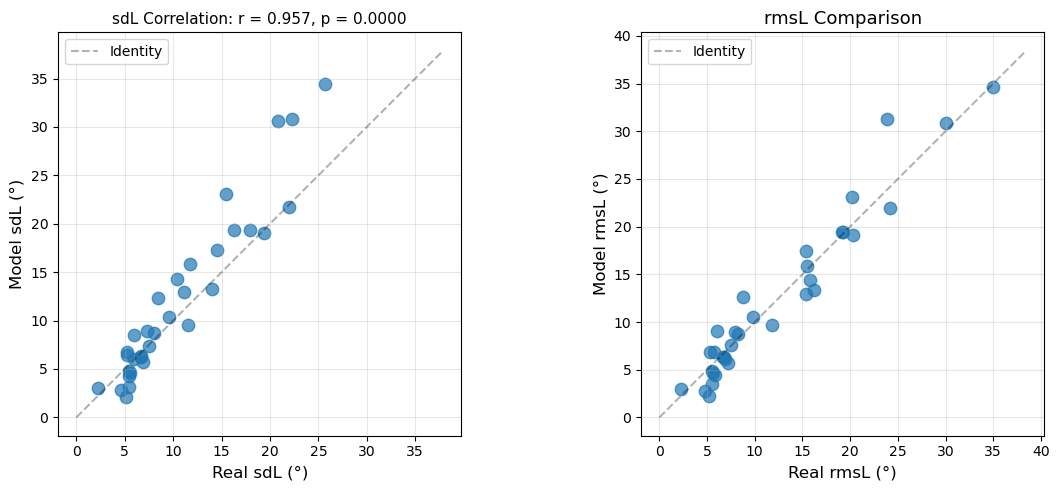

In [30]:

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# sdL correlation
ax = axes[0]
ax.scatter(sdL_real, sdL_model, s=80, alpha=0.7)
lim = max(max(sdL_real), max(sdL_model)) * 1.1
ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='Identity')
ax.set_xlabel('Real sdL (°)', fontsize=12)
ax.set_ylabel('Model sdL (°)', fontsize=12)
ax.set_title(f'sdL Correlation: r = {pearson_r:.3f}, p = {pearson_p:.4f}', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# rmsL comparison
ax = axes[1]
ax.scatter(rmsL_real, rmsL_model, s=80, alpha=0.7)
lim = max(max(rmsL_real), max(rmsL_model)) * 1.1
ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='Identity')
ax.set_xlabel('Real rmsL (°)', fontsize=12)
ax.set_ylabel('Model rmsL (°)', fontsize=12)
ax.set_title('rmsL Comparison', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


In [31]:

print(f"\nMean real rmsL: {np.mean(rmsL_real):.2f}° ± {np.std(rmsL_real)/np.sqrt(31):.2f}°")
print(f"Mean model rmsL: {np.mean(rmsL_model):.2f}° ± {np.std(rmsL_model)/np.sqrt(31):.2f}°")

print(f"\nMean real sdL: {np.mean(sdL_real):.2f}° ± {np.std(sdL_real)/np.sqrt(31):.2f}°")
print(f"Mean model sdL: {np.mean(sdL_model):.2f}° ± {np.std(sdL_model)/np.sqrt(31):.2f}°")


Mean real rmsL: 12.22° ± 1.43°
Mean model rmsL: 12.26° ± 1.54°

Mean real sdL: 10.62° ± 1.10°
Mean model sdL: 12.13° ± 1.53°


## Extended Analysis: rmsL and Bias at Multiple Cutoffs

Compare metrics across different lateral angle ranges (30°, 60°, 90°) to assess robustness.

In [33]:
def rmsL_cutoff(true, est, cutoff):
    """Compute lateral RMS error within ±cutoff° lateral."""
    lat_true = wrap_to_pi(true[..., 0])
    lat_est = wrap_to_pi(est[..., 0])
    mask = np.abs(lat_true) <= np.deg2rad(cutoff)
    if not np.any(mask):
        return np.nan
    diff = wrap_to_pi(lat_est - lat_true)[mask]
    return np.sqrt(np.mean(diff**2))

def accL_cutoff(true, est, cutoff):
    """Compute lateral bias (mean signed error) within ±cutoff° lateral."""
    lat_true = wrap_to_pi(true[..., 0])
    lat_est = wrap_to_pi(est[..., 0])
    mask = np.abs(lat_true) <= np.deg2rad(cutoff)
    if not np.any(mask):
        return np.nan
    diff = wrap_to_pi(lat_est - lat_true)[mask]
    return np.mean(diff)

# Cutoffs to evaluate
cutoffs = [30, 60, 90]

# Initialize results dictionaries
results_by_cutoff = {cutoff: {'rmsL_real': [], 'rmsL_model': [],
                               'accL_real': [], 'accL_model': []}
                     for cutoff in cutoffs}

# Compute metrics for each participant at each cutoff
for pid in participants:
    subj_data = obs_tbl[obs_tbl['participant'] == pid]

    # Real responses
    _resp_arr = np.column_stack([np.deg2rad(subj_data['azi_response'].values),
                                   np.deg2rad(subj_data['ele_response'].values),
                                   np.ones(len(subj_data))])
    resp_coords = pf.Coordinates.from_spherical_elevation(_resp_arr[:, 0], _resp_arr[:, 1], _resp_arr[:, 2])
    resp_hp = resp_coords.spherical_side

    # Target coordinates
    _targ_arr = np.column_stack([np.deg2rad(subj_data['azi_target'].values),
                                   np.deg2rad(subj_data['ele_target'].values),
                                   np.ones(len(subj_data))])
    targ_coords = pf.Coordinates.from_spherical_elevation(_targ_arr[:, 0], _targ_arr[:, 1], _targ_arr[:, 2])
    trial_target_indices = targets_coords.find_nearest(targ_coords)[0][0]
    targ_hp = targets_hp[trial_target_indices, :]

    # Model estimates
    est_lat = model_estimates[pid]['est_lat']
    est_hp = np.column_stack([est_lat, targ_hp[:, 1]])

    # Compute metrics at each cutoff
    for cutoff in cutoffs:
        results_by_cutoff[cutoff]['rmsL_real'].append(np.rad2deg(rmsL_cutoff(targ_hp, resp_hp, cutoff)))
        results_by_cutoff[cutoff]['rmsL_model'].append(np.rad2deg(rmsL_cutoff(targ_hp, est_hp, cutoff)))
        results_by_cutoff[cutoff]['accL_real'].append(np.rad2deg(accL_cutoff(targ_hp, resp_hp, cutoff)))
        results_by_cutoff[cutoff]['accL_model'].append(np.rad2deg(accL_cutoff(targ_hp, est_hp, cutoff)))

# Create summary table
print("=" * 80)
print("SUMMARY: Metrics at Different Lateral Cutoffs")
print("=" * 80)
print(f"{'Cutoff':<10} {'Metric':<10} {'Real (mean±SE)':<20} {'Model (mean±SE)':<20} {'Diff':<10}")
print("-" * 80)

for cutoff in cutoffs:
    # rmsL
    rmsL_real_mean = np.mean(results_by_cutoff[cutoff]['rmsL_real'])
    rmsL_real_se = np.std(results_by_cutoff[cutoff]['rmsL_real']) / np.sqrt(len(participants))
    rmsL_model_mean = np.mean(results_by_cutoff[cutoff]['rmsL_model'])
    rmsL_model_se = np.std(results_by_cutoff[cutoff]['rmsL_model']) / np.sqrt(len(participants))
    rmsL_diff = rmsL_model_mean - rmsL_real_mean

    print(f"±{cutoff}°{' ':<5} {'rmsL':<10} {rmsL_real_mean:6.2f}° ± {rmsL_real_se:4.2f}°{' '*4} "
          f"{rmsL_model_mean:6.2f}° ± {rmsL_model_se:4.2f}°{' '*4} {rmsL_diff:+6.2f}°")

    # accL (bias)
    accL_real_mean = np.mean(results_by_cutoff[cutoff]['accL_real'])
    accL_real_se = np.std(results_by_cutoff[cutoff]['accL_real']) / np.sqrt(len(participants))
    accL_model_mean = np.mean(results_by_cutoff[cutoff]['accL_model'])
    accL_model_se = np.std(results_by_cutoff[cutoff]['accL_model']) / np.sqrt(len(participants))
    accL_diff = accL_model_mean - accL_real_mean

    print(f"{' '*10} {'accL':<10} {accL_real_mean:6.2f}° ± {accL_real_se:4.2f}°{' '*4} "
          f"{accL_model_mean:6.2f}° ± {accL_model_se:4.2f}°{' '*4} {accL_diff:+6.2f}°")
    print("-" * 80)

# Compute implied bias from rms² = bias² + sd² for 30° cutoff
print("\nIMPLIED BIAS from rms² = bias² + sd² relationship (±30° cutoff):")
print("-" * 80)
rms_30_real = np.mean(results_by_cutoff[30]['rmsL_real'])
sd_30_real = np.mean(sdL_real)
bias_implied_real = np.sqrt(max(0, rms_30_real**2 - sd_30_real**2))

rms_30_model = np.mean(results_by_cutoff[30]['rmsL_model'])
sd_30_model = np.mean(sdL_model)
bias_implied_model = np.sqrt(max(0, rms_30_model**2 - sd_30_model**2))

print(f"Real:  √(rms² - sd²) = √({rms_30_real:.2f}² - {sd_30_real:.2f}²) = {bias_implied_real:.2f}°")
print(f"Model: √(rms² - sd²) = √({rms_30_model:.2f}² - {sd_30_model:.2f}²) = {bias_implied_model:.2f}°")
print(f"\nDirect accL measure at ±30°: Real={np.mean(results_by_cutoff[30]['accL_real']):.2f}°, "
      f"Model={np.mean(results_by_cutoff[30]['accL_model']):.2f}°")

SUMMARY: Metrics at Different Lateral Cutoffs
Cutoff     Metric     Real (mean±SE)       Model (mean±SE)      Diff      
--------------------------------------------------------------------------------
±30°      rmsL        12.22° ± 1.39°      12.26° ± 1.49°      +0.05°
           accL         2.86° ± 1.29°      -0.02° ± 0.34°      -2.88°
--------------------------------------------------------------------------------
±60°      rmsL        16.21° ± 1.01°      12.72° ± 1.53°      -3.49°
           accL         3.23° ± 1.23°      -0.02° ± 0.27°      -3.24°
--------------------------------------------------------------------------------
±90°      rmsL        16.22° ± 0.91°      13.24° ± 1.47°      -2.98°
           accL         3.17° ± 1.12°      -0.12° ± 0.27°      -3.29°
--------------------------------------------------------------------------------

IMPLIED BIAS from rms² = bias² + sd² relationship (±30° cutoff):
------------------------------------------------------------------------

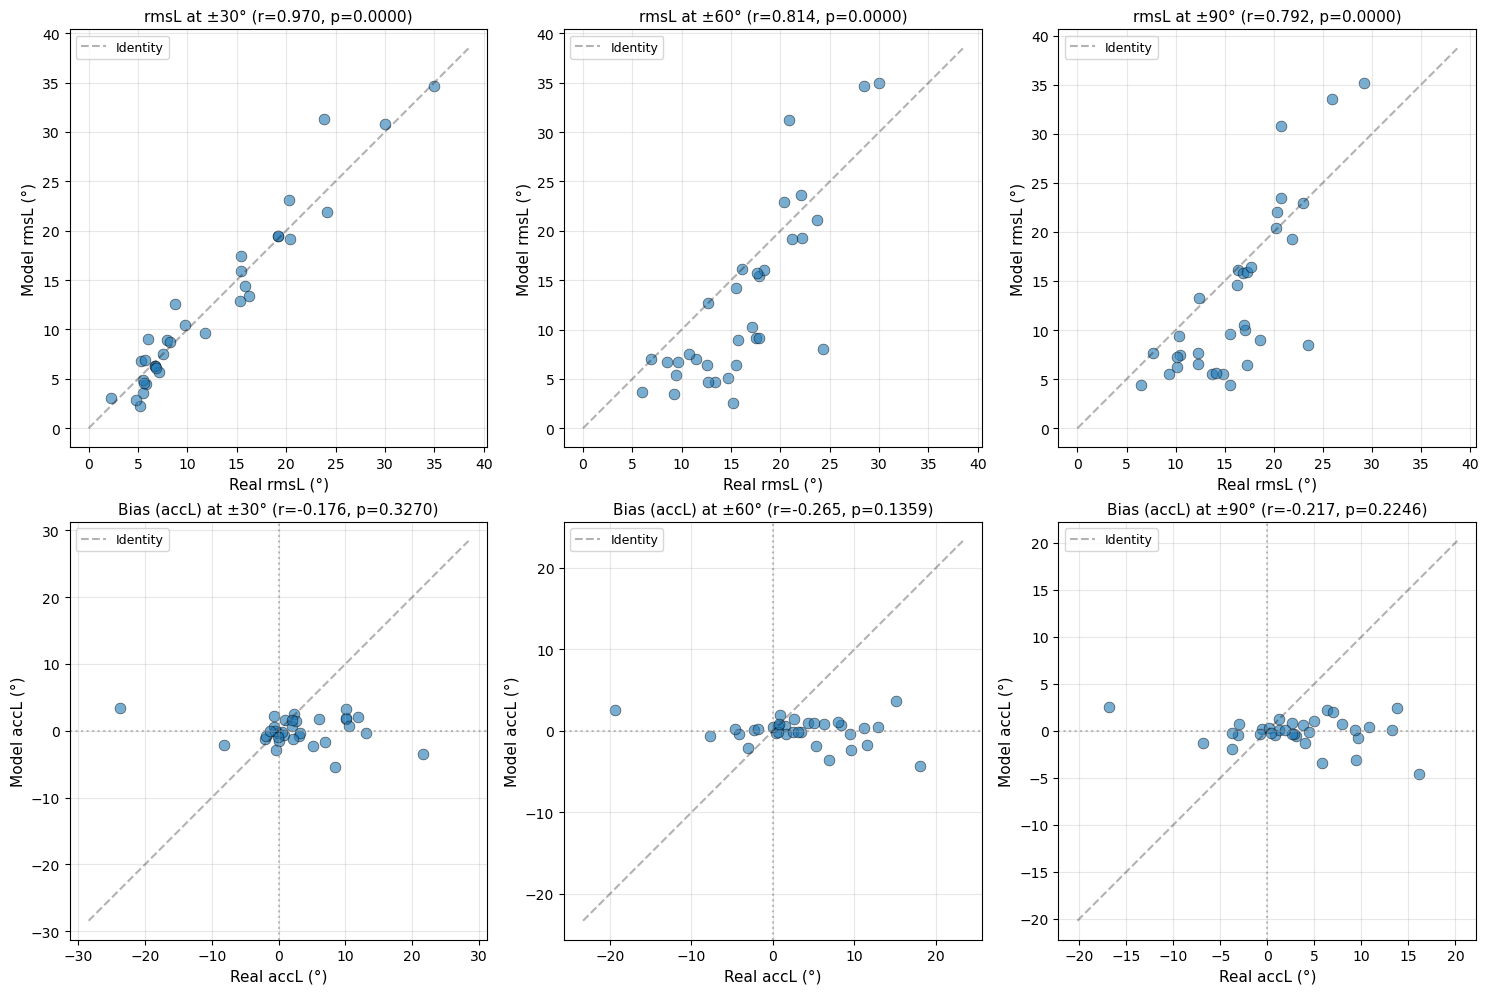

In [34]:
# Visualize metrics across cutoffs
fig, axes = plt.subplots(2, 3, figsize=(15, 10))


for idx, cutoff in enumerate(cutoffs):
    # rmsL scatter plot
    ax = axes[0, idx]
    real_rms = results_by_cutoff[cutoff]['rmsL_real']
    model_rms = results_by_cutoff[cutoff]['rmsL_model']

    ax.scatter(real_rms, model_rms, s=60, alpha=0.6, edgecolors='k', linewidth=0.5)
    lim = max(max(real_rms), max(model_rms)) * 1.1
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='Identity')

    # Compute correlation
    r, p = pearsonr(real_rms, model_rms)

    ax.set_xlabel(f'Real rmsL (°)', fontsize=11)
    ax.set_ylabel(f'Model rmsL (°)', fontsize=11)
    ax.set_title(f'rmsL at ±{cutoff}° (r={r:.3f}, p={p:.4f})', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    # accL (bias) scatter plot
    ax = axes[1, idx]
    real_acc = results_by_cutoff[cutoff]['accL_real']
    model_acc = results_by_cutoff[cutoff]['accL_model']

    ax.scatter(real_acc, model_acc, s=60, alpha=0.6, edgecolors='k', linewidth=0.5)
    lim = max(abs(min(min(real_acc), min(model_acc))),
              max(max(real_acc), max(model_acc))) * 1.2
    ax.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.3, label='Identity')
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(0, color='gray', linestyle=':', alpha=0.5)

    # Compute correlation
    r, p = pearsonr(real_acc, model_acc)

    ax.set_xlabel(f'Real accL (°)', fontsize=11)
    ax.set_ylabel(f'Model accL (°)', fontsize=11)
    ax.set_title(f'Bias (accL) at ±{cutoff}° (r={r:.3f}, p={p:.4f})', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()